In [15]:
import pandas as pd


In [16]:
X_train=pd.read_csv('X_train_scaled.csv')
X_test=pd.read_csv('X_test_scaled.csv')
y_train=pd.read_csv('y_train_sca.csv')
y_test=pd.read_csv('y_test_scaa.csv')

In [17]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(299, 19) (75, 19) (299, 1) (75, 1)


C:\Users\ST\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


X_train_selected: (299, 8)
X_test_selected: (75, 8)


C:\Users\ST\AppData\Local\Temp\ipykernel_9704\1689989413.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Score', data=feature_scores.head(k), palette='viridis')


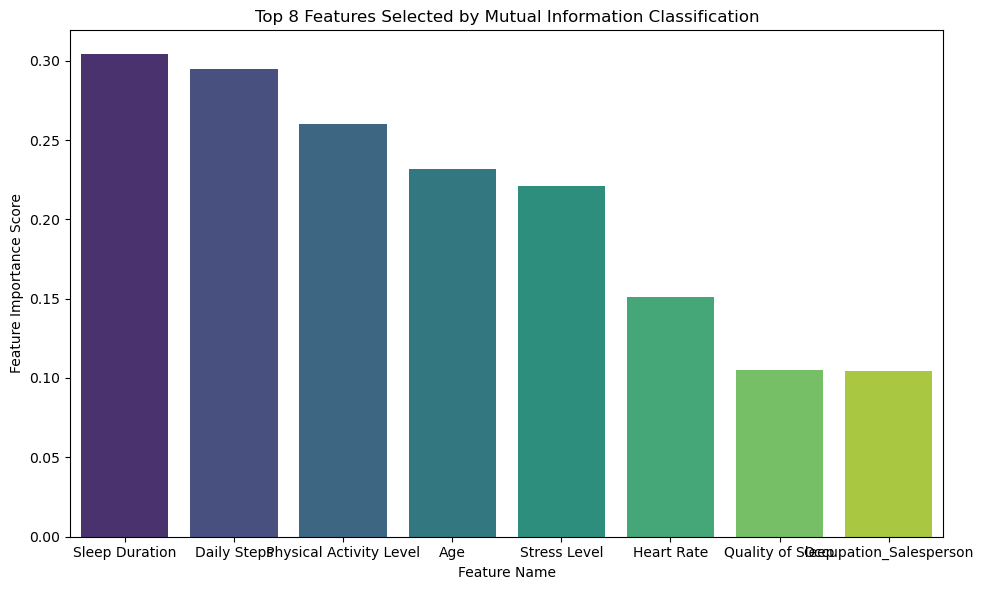

In [18]:
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2, f_classif  # for classification
import seaborn as sns
import matplotlib.pyplot as plt
k=8
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

scores = selector.scores_
selected_features = X_train.columns[selector.get_support()]
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': scores
}).sort_values(by='Score', ascending=False)

X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_test_selected = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)
print("X_train_selected:", X_train_selected.shape)
print("X_test_selected:", X_test_selected.shape)

plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Score', data=feature_scores.head(k), palette='viridis')
plt.title(f'Top {k} Features Selected by Mutual Information Classification')
plt.xlabel('Feature Name')
plt.ylabel('Feature Importance Score')
# plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [19]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(299, 19) (75, 19) (299, 1) (75, 1)


In [20]:
X_train_selected.to_csv('X_train_selected.csv',index=False)
X_test_selected.to_csv('X_test_selected.csv',index=False)
y_train.to_csv('y_train_trrrrr.csv',index=False)
y_test.to_csv('y_test_triii.csv',index=False)

In [21]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

model = Sequential()
# model.add(Dense(512,activation='relu',input_dim=8))
model.add(Dense(128,activation='relu',input_dim=8,kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(256,activation='relu'))
# model.add(Dense(64,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

C:\Users\ST\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
opt = keras.optimizers.Adam(learning_rate=0.001) 
model.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [23]:
from keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
#Early stopping
es = EarlyStopping(monitor= 'val_loss', patience= 5, verbose= 1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=np.sqrt(0.1), patience=3)
#Model check point
# mc = ModelCheckpoint(filepath= r'E:\Harumanis Mango Leaves Dataset 2021\Python\Mango Leaf Disease\Harumanis Mango Leaves Dataset 2021\Final Code\Model_MetaData\best_model_FT_DenseNet1212_1.h5', 
# mc = ModelCheckpoint(filepath= r'D:\Teaching\WUB\Research\Latest\Waste Classification\Waste Classification Dataset\Model_MetaData\best_model_FT32_DenseNet121_22WAbinary.h5', 
#                      monitor= 'val_loss', 
#                      verbose= 1, 
#                      save_best_only= True,mode='min')

cb = [es,reduce_lr]

history = model.fit(X_train_selected,y_train,batch_size=32,epochs=200,validation_split=0.2,verbose=1,callbacks=[cb])

ValueError: Invalid dtype: object

In [24]:
y_pred = model.predict(X_test_selected)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 


In [25]:
y_pred

array([[0.48846826],
       [0.49719855],
       [0.500512  ],
       [0.48846826],
       [0.49726695],
       [0.4970792 ],
       [0.4973606 ],
       [0.48739094],
       [0.48964033],
       [0.48772758],
       [0.51009095],
       [0.49264517],
       [0.48795265],
       [0.49726695],
       [0.48795265],
       [0.49102354],
       [0.49579048],
       [0.51009095],
       [0.48964033],
       [0.48775718],
       [0.49250615],
       [0.4848896 ],
       [0.49728718],
       [0.49096394],
       [0.49088243],
       [0.48876205],
       [0.51009095],
       [0.5110415 ],
       [0.5110415 ],
       [0.48775578],
       [0.49132526],
       [0.48824543],
       [0.4921165 ],
       [0.48687342],
       [0.4911125 ],
       [0.48739094],
       [0.49711716],
       [0.49261728],
       [0.48795265],
       [0.48608482],
       [0.5108179 ],
       [0.49102354],
       [0.49538818],
       [0.5110415 ],
       [0.48751652],
       [0.48739094],
       [0.49141708],
       [0.484

In [26]:
y_pred = (y_pred > 0.5).astype(int).ravel()
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0])

In [27]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,matthews_corrcoef, ConfusionMatrixDisplay

accu= accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
fs = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Test Accuracy:     {accu}")
print(f"Test Precision: {prec}")
print(f"Test Recall:     {rec}")
print(f"Test F1_Score: {fs}")
print(f"Test MCC: {mcc}")

TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=['Insomnia' 'Sleep Apnea'] and y_pred=[0 1]. Make sure that the predictions provided by the classifier coincides with the true labels.